In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

from DoE_module import x2fx, standardize, dispersion, corrcov

from ipywidgets import interact, FloatSlider

import seaborn as sns
sns.set_theme()

def show_matrix(m: pd.DataFrame, cmap="coolwarm", cbar=False, annot=True, **kwargs):
    axim = sns.heatmap(m.rename(columns=dict(Intercep="I")), cmap=cmap, cbar=cbar, annot=annot, **kwargs)
    axim.xaxis.set_ticks_position("top")
    axim.yaxis.set_ticks_position("right")

# Series 3: Sensitivity of the Young modulus

## Statement
The data is relative to a set of experiments on steal samples with different concentration in carbon and sulfure, tested at different temperatures in order to determine the elastic behavior of the material.The content of the table corresponds to the experimental conditions as well as the Young modulus following the Hooke phenomenological relation:

$$\varepsilon = \frac{\sigma}{E}$$

with $\varepsilon$ the strain, $\sigma$ the longitudinat stress and $E$ the Young modulus.

## Data loading
- Load the experimental data from the provided data file into a table for analysis.

## Pre-experiment Model Analysis
(before experiment execution)
- Critically analyze the design of the experiment for both a linear model and a model including interactions between carbon (C) and sulfur (S).
- For each model, determine and document:
    - The model equation,
    - The dispersion and correlation matrices,
    - The Variance Inflation Factor (VIF) for multicollinearity,
    - The overall variance of the model.
- Summarize these elements and prepare a set of recommendations for the experimenters, assuming the experiments have not yet been conducted.

## Post-experiment Analysis
(after experiment execution)
- Infer the main effects and the interaction between the concentration of carbon (C) and sulfur (S) on the Young’s modulus of the material, using normalized metrics.
- Transform the estimated coefficients back into their original metrics for practical interpretation.

## Confidence Interval Calculation
- Compute the 95% confidence intervals for all the model coefficients to assess the precision of the estimates.

## Conclusion Preparation
- Draft a preliminary conclusion for a report that reflects the results of the experiment, focusing on the quality of the measurements and their implications.

## Future Experiment Recommendations:
- Prepare recommendations for a second experimental campaign that includes an evaluation of potential interactions with temperature. Suggest any design improvements needed to study these new factors.

# 1 - Importing data from excel

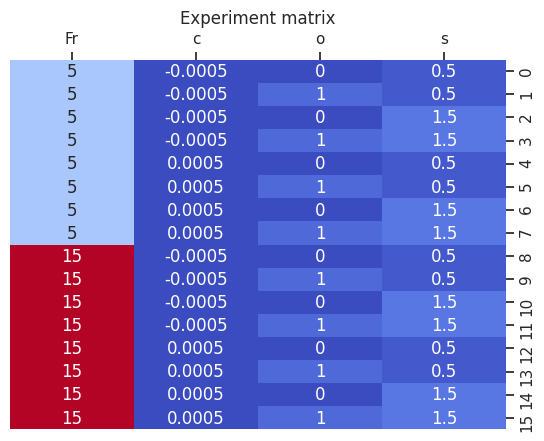

In [12]:
df = pd.read_csv("matrix_experiment.csv")
show_matrix(df)
plt.title("Experiment matrix")
plt.show()

# 2 - Analyzing of the design

The steps are :

a) Extraction of the matrix of essays from the data

b) Normalization of the matrix of essays

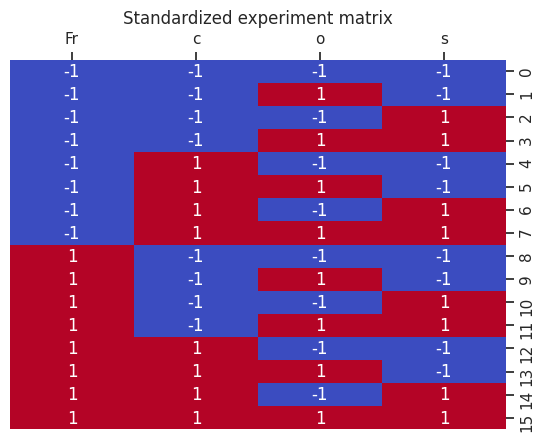

In [13]:
E = standardize(df)
show_matrix(np.round(E, 3))
plt.title("Standardized experiment matrix")
plt.show()

c) Building of the model matrix for the linear model with interaction

$$y = a_0 + a_C x_C + a_S x_S + s_T x_T + a_{CS} x_C x_S$$

We use the coefficient spec matrix with one column per factor and one row per coefficient.
Then for our situation the matrix is

$$\text{spec}=\begin{pmatrix}
    0 & 0 & 0\\
    1 & 0 & 0\\
    0 & 1 & 0\\
    0 & 0 & 1\\
    1 & 1 & 0\\
\end{pmatrix}$$

for the coefficients $a_C$, $a_S$, $a_T$ and $a_{CS}$.

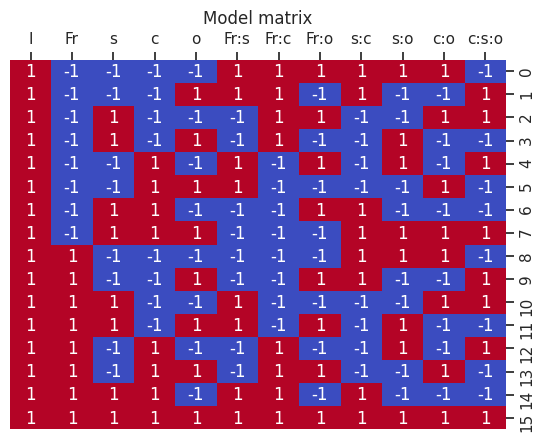

In [14]:
M = pd.read_csv("matrix_model.csv")
show_matrix(M)
plt.title("Model matrix")
plt.show()

d) Computation of the dispersion matrix

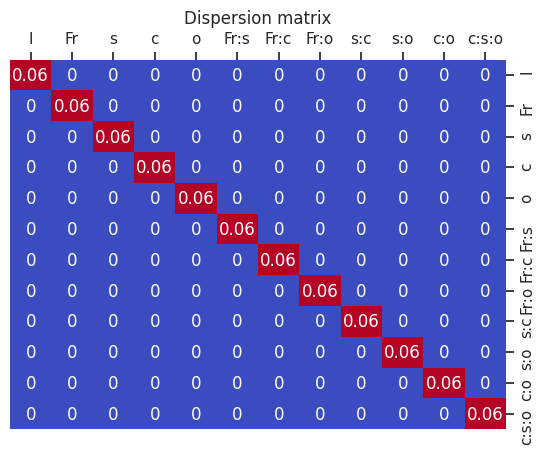

In [15]:
D = dispersion(M)

list_coefs = M.columns
D = pd.DataFrame(np.round(D, 2),
                 columns=list_coefs,
                 index=list_coefs)
show_matrix(D)
plt.title("Dispersion matrix")
plt.show()

e) Computation of the correlation matrix

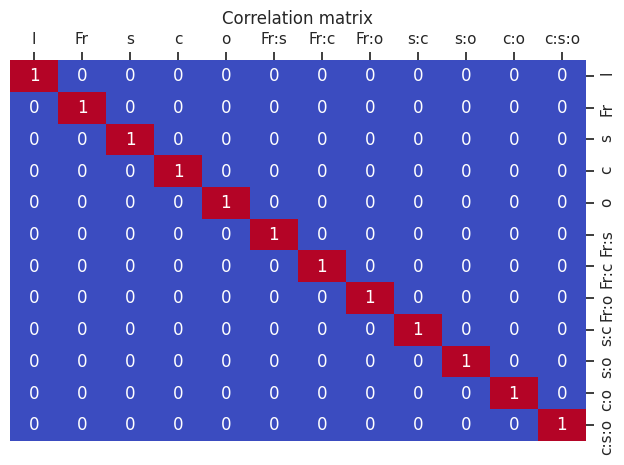

In [16]:
C = corrcov(D)
plt.figure(layout="tight")
show_matrix(pd.DataFrame(np.round(C, 2),
                     columns=list_coefs,
                     index=list_coefs))
plt.title("Correlation matrix")
plt.show()

We can observe a correlation of -0.5 between the main effects of carbon and and sulfur, as well as between the constant $a_0$ and the interaction effect $a_{SC}$.

A correlation coefficient of -0.5 between the estimates of two main effects in a linear model with interactions suggests a moderate negative correlation. Here are some possible comments and interpretations you could make on this value:
1. **Moderate Negative Correlation:** The value of -0.5 indicates that as one main effect increases, the other tends to decrease, but the relationship is not perfectly linear. It’s a moderate inverse relationship, suggesting that there is some dependency between these two main effects.
2. **Multicollinearity Concern:** While a correlation of -0.5 does not indicate severe multicollinearity (which would generally be observed with correlations closer to -1 or 1), it does point to some level of association between these variables. This could influence the stability of the coefficient estimates in the model. You might want to further explore the Variance Inflation Factor (VIF) for a more robust assessment of multicollinearity.
3. **Impact on Interpretation:** When interpreting the results, it’s important to note that the negative correlation between the two main effects may make it more difficult to separate their individual impacts on the response variable. This interdependence could lead to some confounding in the interpretation of their coefficients.

In summary, while a correlation of -0.5 is not necessarily alarming, it does warrant attention and further investigation to ensure that the model coefficients are reliable and interpretable.

f) Computation of the variance inflation factors (VIF)

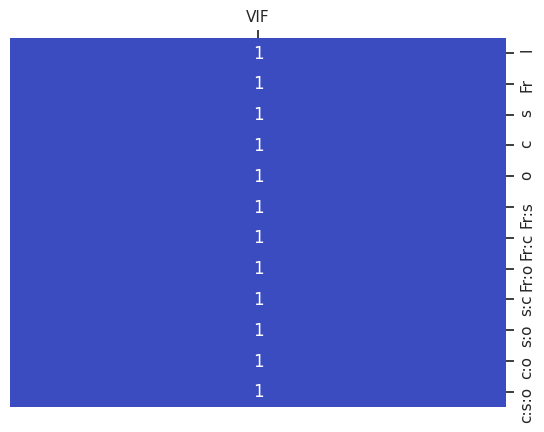

In [17]:
VIF = np.diag(np.linalg.inv(C))
show_matrix(pd.DataFrame(np.round(VIF, 2),
                     columns=["VIF"],
                     index=list_coefs))
plt.show()

Theses VIF values between 1 and 1.33 indicate a well-behaved model with respect to multicollinearity. There is minimal correlation between the regressors, and this should allow for clear interpretation of the main effects and interactions. No corrective action is needed for multicollinearity based on these values.

g) **Plot** of the position of the measurement points

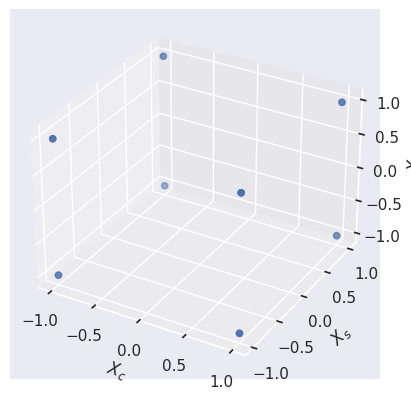

In [18]:
ax = plt.subplot(projection="3d")
ax.scatter(E.c, E.s, E.o)
ax.set_xlabel("$X_c$")
ax.set_ylabel("$X_s$")
ax.set_zlabel("$X_o$")
plt.show()

Even if the distribution of the points of measurements is non uniform, the design is spread all over the experimental space. This ensure a good estimation of the linear coefficients (but not for the interaction coefficients between the temperature and the two other factors).

h) Computation of the **variance function**

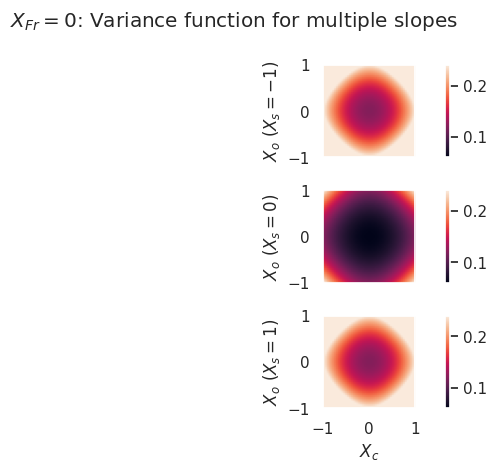

In [19]:
%matplotlib inline
n = 50
xc = np.linspace(-1, 1, num=n)
xs = np.linspace(-1, 1, num=n)
xo = np.linspace(-1, 1, num=n)
XF = np.zeros((n, n))
XI = np.ones((n, n))

def variance_s(xs, xf=0):
    Xc, Xo = np.meshgrid(xc, xo, indexing="ij")
    Xs = np.full((n, n), xs)
    XF = np.full((n, n), xf)
    fx = np.array([
        XI,
        XF,
        Xc, 
        Xs,
        Xo,
        XF*Xc,
        XF*Xs,
        XF*Xo,
        Xs*Xc,
        Xs*Xo,
        Xc*Xo,
        Xc*Xs*Xo,
    ])
    return np.einsum("i...,ij,j...->...", fx, D, fx)

v1 = variance_s(-1)
v2 = variance_s(+0)
v3 = variance_s(+1)
vmin = min(v1.min(), v2.min(), v3.min())
vmax = min(v1.max(), v2.max(), v3.max())

fig, axes = plt.subplots(nrows=3, layout="tight", sharex="all", sharey="all")
fig.suptitle(r"$X_{Fr} = 0$: Variance function for multiple slopes")
for ax, xs_i, v in zip(axes, (-1, 0, 1), (v1, v2, v3)):
    im = ax.imshow(v, extent=(-1, 1, -1, 1), vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax)
    ax.set_ylabel(f"$X_o$ ($X_s = {xs_i}$)")
    ax.grid(False)
ax.set_xlabel("$X_c$")
plt.show()

In [20]:
%matplotlib inline

def ivariance_s(xs, xf):
    v = variance_s(xs, xf)
    plt.title(f"Variance function $X_{{Fr}}={xf:.2f}$, $X_s={xs:.2f}$")
    plt.imshow(v, extent=(-1, 1, -1, 1), vmin=vmin, vmax=vmax)
    plt.grid(False)
    plt.xlabel("$X_c$")
    plt.ylabel("$X_o$")
    plt.colorbar()
    plt.show()
print(vmin, vmax)
i = interact(
    ivariance_s,
    xs=FloatSlider(min=-1, max=1, value=0),
    xf=FloatSlider(min=-1, max=1, value=0),
)

0.060049989583335135 0.24


interactive(children=(FloatSlider(value=0.0, description='xs', max=1.0, min=-1.0), FloatSlider(value=0.0, desc…